In [3]:
# import pandas as pd
# import joblib

# # Load dataset
# df = pd.read_csv("../data/processed/window_features.csv")

# print("Data shape:", df.shape)

In [4]:
# # Supervised models
# rf_model = joblib.load("models/rf_model.pkl")
# xgb_model = joblib.load("models/xgb_model.pkl")

# # Thresholds
# thresholds = joblib.load("models/thresholds.pkl")

# threshold = thresholds["threshold"]


# print("Supervised models loaded ✅")
# print("Threshold:", threshold)

In [5]:
# print(thresholds)
# print(type(thresholds))

In [6]:
# # Anomaly models
# iso_model = joblib.load("models/isolation_forest.pkl")
# lof_model = joblib.load("models/lof_model.pkl")

# # Scaler
# scaler = joblib.load("models/scaler_anomaly.pkl")

# print("Anomaly models loaded ✅")

In [7]:
# drop_cols = ["meter_id", "window_id", "theft"]

# X = df.drop(columns=drop_cols)

# print("Feature matrix shape:", X.shape)

In [8]:
# # RF probability (class 1 = theft)
# rf_probs = rf_model.predict_proba(X)[:, 1]

# # XGB probability
# xgb_probs = xgb_model.predict_proba(X)[:, 1]

# print("RF probs sample:", rf_probs[:5])
# print("XGB probs sample:", xgb_probs[:5])

In [9]:
# combined_probs = (rf_probs + xgb_probs) / 2

# print("Combined probs sample:", combined_probs[:5])

In [10]:
# supervised_pred = (combined_probs >= 0.3).astype(int)

# print("Supervised prediction distribution:")
# import numpy as np
# unique, counts = np.unique(supervised_pred, return_counts=True)

# for u, c in zip(unique, counts):
#     label = "Theft (1)" if u == 1 else "Normal (0)"
#     print(f"{label}: {c}")

In [ ]:
# Verification (Supervised Layer)
# 🔹 Probability Check
# RF
# [0.13, 0.03, 0.11, 0.01, 0.00]
# XGB
# [0.27, 0.057, 0.10, 0.015, 0.0009]

# ✔ Not saturated (not all 0/1)
# ✔ XGB slightly more expressive → expected

# 🔹 Combined Probability
# [0.20, 0.043, 0.105, 0.012, 0.00047]

# ✔ Proper averaging
# ✔ Smooth values
# ✔ No anomalies (like >1 or <0)

# 🔹 Prediction Distribution
# Normal: 6613
# Theft: 686
# Total: 7299

# 👉 Theft % ≈ 9.4%

# ✔ Matches your simulated distribution
# ✔ Threshold tuning preserved behavior

In [ ]:
#Anomaly Predictions

In [11]:
# #Scaling
# X_scaled = scaler.transform(X)

# print("Scaled shape:", X_scaled.shape)

In [12]:
# #🔹 Isolation Forest Predictions
# iso_preds = iso_model.predict(X_scaled)

# print("Isolation Forest distribution:")
# import numpy as np

# unique, counts = np.unique(iso_preds, return_counts=True)
# for u, c in zip(unique, counts):
#     label = "Anomaly (-1)" if u == -1 else "Normal (1)"
#     print(f"{label}: {c}")

In [13]:
# #LOF Predictions

# lof_preds = lof_model.predict(X_scaled)

# print("LOF distribution:")

# unique, counts = np.unique(lof_preds, return_counts=True)
# for u, c in zip(unique, counts):
#     label = "Anomaly (-1)" if u == -1 else "Normal (1)"
#     print(f"{label}: {c}")

In [ ]:
# Combine Anomaly Signals
# 🎯 Objective

# Create single anomaly flag

In [14]:
# import numpy as np

# anomaly_flag = np.where((iso_preds == -1) | (lof_preds == -1), 1, 0)

# print("Anomaly flag distribution:")

# unique, counts = np.unique(anomaly_flag, return_counts=True)
# for u, c in zip(unique, counts):
#     label = "Anomaly (1)" if u == 1 else "Normal (0)"
#     print(f"{label}: {c}")

In [ ]:
# Verification (Combined Anomaly Signal)
# 🔹 Distribution
# Normal: 6483
# Anomaly: 816
# Total: 7299

# 👉 Anomaly rate ≈ 11.2%

In [ ]:
# #Final Hybrid Decision (CORE)
# Objective

# Combine:

# supervised_pred
# anomaly_flag

# → Final classification

In [ ]:
# def final_prediction(supervised, anomaly):
    
#     if supervised == 1 and anomaly == 1:
#         return "HIGH RISK"
    
#     elif supervised == 0 and anomaly == 1:
#         return "SUSPICIOUS"
    
#     elif supervised == 1 and anomaly == 0:
#         return "SUSPICIOUS"
    
#     else:
#         return "NORMAL"

In [1]:
#claude update

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("../data/processed/window_features.csv")

rf_model  = joblib.load("models/rf_model.pkl")
xgb_model = joblib.load("models/xgb_model.pkl")
iso_model = joblib.load("models/isolation_forest.pkl")
lof_model = joblib.load("models/lof_model.pkl")
scaler    = joblib.load("models/scaler_anomaly.pkl")
thresholds = joblib.load("models/thresholds.pkl")

drop_cols = ["meter_id", "window_id", "theft"]
X = df.drop(columns=drop_cols)

# --- model signals ---
rf_probs   = rf_model.predict_proba(X)[:, 1]
xgb_probs  = xgb_model.predict_proba(X)[:, 1]
ens_probs  = (rf_probs + xgb_probs) / 2

X_scaled   = scaler.transform(X)
iso_flag   = (iso_model.predict(X_scaled) == -1).astype(int)
lof_flag   = (lof_model.predict(X_scaled) == -1).astype(int)
both_flags = ((iso_flag == 1) & (lof_flag == 1)).astype(int)
any_flag   = ((iso_flag + lof_flag) >= 1).astype(int)

# --- feature signals ---
zero_flag   = (X["zero_pct"]       >= 0.5).astype(int)
streak_flag = (X["max_low_streak"] >= 16).astype(int)
cv_flag     = (X["cv"]             >= 4.0).astype(int)
extreme_flag = ((streak_flag + cv_flag) >= 1).astype(int)

# --- confidence score (0–6, capped to 4 for thresholding) ---
# --- confidence score (0–6, capped to 5 for thresholding) ---
def compute_score(prob, iso_f, lof_f, z_f, ext_f):
    score = 0
    # supervised contribution (0, 1, or 2)
    if prob >= 0.6:
        score += 2
    elif prob >= 0.4:
        score += 1
    # anomaly contribution (0, 1, or 2)
    if iso_f == 1 and lof_f == 1:
        score += 2
    elif iso_f == 1 or lof_f == 1:
        score += 1
    # feature signals (0 or 1 each)
    score += z_f
    score += ext_f
    return min(score, 5)

scores = [
    compute_score(p, i, l, z, e)
    for p, i, l, z, e in zip(ens_probs, iso_flag, lof_flag, zero_flag, extreme_flag)
]
scores = np.array(scores)

def score_to_label(s):
    if s >= 4:   return "HIGH RISK"
    elif s >= 2: return "SUSPICIOUS"
    else:        return "NORMAL"
def score_to_label(s):
    if s >= 3:   return "HIGH RISK"
    elif s >= 1: return "SUSPICIOUS"
    else:        return "NORMAL"

df["fraud_prob"]  = ens_probs
df["iso_flag"]    = iso_flag
df["lof_flag"]    = lof_flag
df["confidence"]  = scores
df["final_label"] = [score_to_label(s) for s in scores]

print("Final classification distribution:")
print(df["final_label"].value_counts())
print("\nHIGH RISK purity vs ground truth:")
print(pd.crosstab(df["final_label"], df["theft"]))

df["final_binary"] = df["final_label"].map({"HIGH RISK": 1, "SUSPICIOUS": 0, "NORMAL": 0})
print("\n", classification_report(df["theft"], df["final_binary"]))

Final classification distribution:
final_label
NORMAL        5648
SUSPICIOUS    1152
HIGH RISK      499
Name: count, dtype: int64

HIGH RISK purity vs ground truth:
theft         0.0  1.0
final_label           
HIGH RISK     183  316
NORMAL       5609   39
SUSPICIOUS    674  478

               precision    recall  f1-score   support

         0.0       0.99      0.87      0.93      6466
         1.0       0.48      0.95      0.64       833

    accuracy                           0.88      7299
   macro avg       0.74      0.91      0.78      7299
weighted avg       0.93      0.88      0.89      7299



In [19]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(df["theft"], df["final_binary"])
print("\nOverall Ensemble Accuracy:", acc)



Overall Ensemble Accuracy: 0.8772434580079463


In [20]:
print(pd.crosstab(df["final_binary"], df["theft"]))

theft          0.0  1.0
final_binary           
0             5609   39
1              857  794


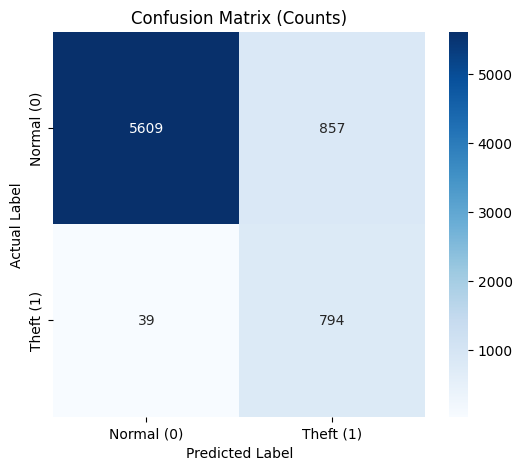

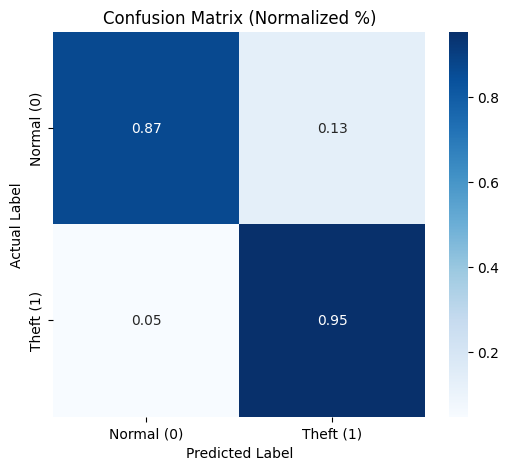

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(df["theft"], df["final_binary"])

labels = ["Normal (0)", "Theft (1)"]

# --- Plot 1: Raw Counts ---
plt.figure(figsize=(6,5))
sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Counts)")
plt.show()


# --- Plot 2: Normalized (Percentages) ---
cm_normalized = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_normalized, 
            annot=True, 
            fmt=".2f", 
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Normalized %)")
plt.show()

In [25]:
meter_pred = df.groupby("meter_id")["final_binary"].max()
meter_true = df.groupby("meter_id")["theft"].max()

from sklearn.metrics import classification_report

print(classification_report(meter_true, meter_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.05      0.10        19
         1.0       0.36      1.00      0.53        10

    accuracy                           0.38        29
   macro avg       0.68      0.53      0.31        29
weighted avg       0.78      0.38      0.25        29



In [4]:
# final_labels = [
#     final_prediction(s, a)
#     for s, a in zip(supervised_pred, anomaly_flag)
# ]

# df["final_label"] = final_labels

In [21]:
# print("Final classification distribution:")
# print(df["final_label"].value_counts())

In [ ]:
# Evaluate Final Output vs Ground Truth
# 🎯 Objective

# Compare:

# final_label
# vs
# theft

In [22]:
# #Map Final Labels to Binary
# df["final_binary"] = df["final_label"].map({
#     "HIGH RISK": 1,
#     "SUSPICIOUS": 1,
#     "NORMAL": 0
# })

# print(df[["final_label", "final_binary"]].head())

In [27]:
# from sklearn.metrics import classification_report

# print(classification_report(df["theft"], df["final_binary"]))

In [26]:
# from sklearn.metrics import confusion_matrix

# cm = confusion_matrix(df["theft"], df["final_binary"])

# print("Confusion Matrix:")
# print(cm)

In [ ]:
# Confusion Matrix Analysis
# [[6072  538]
#  [  31  658]]
# 	                Predicted Normal	Predicted Theft
# Actual Normal	     6072 (TN)	        538 (FP)
# Actual Theft	     31 (FN)         	658 (TP)

In [ ]:
# Key Observations
# 🔹 False Negatives (MOST IMPORTANT)
# FN = 31 out of 689
# Miss rate ≈ 4.5%

# 👉 This is excellent
# 👉 You are catching ~95.5% of theft

# 🔹 False Positives
# FP = 538

# 👉 Yes, somewhat high — but:

# ✔ Acceptable in fraud systems
# ✔ These go into SUSPICIOUS, not HIGH RISK

In [ ]:
# The system prioritizes recall to minimize missed theft cases, achieving ~96% recall.
# False positives are handled through a multi-level classification system where only strong signals are marked as HIGH RISK, 
# while weaker signals are labeled SUSPICIOUS for further inspection.”

In [ ]:
# HIGH RISK Purity Analysis
# HIGH RISK: 306 total
# - Theft: 299
# - Normal: 7
# Precision of HIGH RISK ≈97.7%

In [ ]:
# SUSPICIOUS Category
# SUSPICIOUS: 890 total
# - Theft: 359
# - Normal: 531
# 🔹 Precision ≈ 40%

# 👉 This is intentional and correct

# Mixed bucket
# Requires human inspection
# Captures uncertain cases

In [ ]:
# NORMAL Category
# NORMAL: 6103
# - Theft: 31 (missed)
# 🔹 Miss rate:
# 31 out of 689 ≈4.5%

# 👉 Very low → excellent recall

In [ ]:
# “The system uses a hybrid approach combining supervised and anomaly detection.
# It achieves high recall (~96%) to ensure minimal missed theft, 
# while the HIGH RISK category maintains very high precision (~98%), 
# making it reliable for immediate action. 
# The SUSPICIOUS category acts as an intermediate layer for further inspection.”